# Phase 2: Explore the ciphers

This notebook compares ciphertext structure only. It does not attempt decryption.

In [1]:
from collections import Counter
from pathlib import Path
import json
import math
import matplotlib.pyplot as plt

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
paths = sorted((root / 'data' / 'raw').glob('z*.json'))
ciphers = {}
for path in paths:
    record = json.loads(path.read_text())
    ciphers[record['cipher']] = [symbol for row in record['rows'] for symbol in row]

assert {name: len(symbols) for name, symbols in ciphers.items()} == {'Z13': 13, 'Z32': 32, 'Z340': 340, 'Z408': 408}
list(ciphers)

Matplotlib is building the font cache; this may take a moment.


['Z13', 'Z32', 'Z340', 'Z408']

In [2]:
def repeated_ngrams(symbols, n):
    counts = Counter(tuple(symbols[i:i + n]) for i in range(len(symbols) - n + 1))
    return {gram: count for gram, count in counts.items() if count > 1}

def metrics(symbols):
    counts = Counter(symbols)
    size = len(symbols)
    probabilities = [count / size for count in counts.values()]
    return {
        'length': size,
        'unique_symbols': len(counts),
        'entropy_bits': -sum(p * math.log2(p) for p in probabilities),
        'index_of_coincidence': sum(count * (count - 1) for count in counts.values()) / (size * (size - 1)),
        'repeated_bigrams': len(repeated_ngrams(symbols, 2)),
        'repeated_trigrams': len(repeated_ngrams(symbols, 3)),
    }

results = {name: metrics(symbols) for name, symbols in ciphers.items()}
for name, values in results.items():
    print(name, {key: round(value, 4) if isinstance(value, float) else value for key, value in values.items()})

Z13 {'length': 13, 'unique_symbols': 9, 'entropy_bits': 3.027, 'index_of_coincidence': 0.0641, 'repeated_bigrams': 0, 'repeated_trigrams': 0}
Z32 {'length': 32, 'unique_symbols': 29, 'entropy_bits': 4.8125, 'index_of_coincidence': 0.006, 'repeated_bigrams': 0, 'repeated_trigrams': 0}
Z340 {'length': 340, 'unique_symbols': 64, 'entropy_bits': 5.7523, 'index_of_coincidence': 0.0194, 'repeated_bigrams': 20, 'repeated_trigrams': 2}
Z408 {'length': 408, 'unique_symbols': 49, 'entropy_bits': 5.512, 'index_of_coincidence': 0.0211, 'repeated_bigrams': 59, 'repeated_trigrams': 10}


In [3]:
for name, symbols in ciphers.items():
    print(f'{name} most common symbols:', Counter(symbols).most_common(10))
    for n in (2, 3):
        repeats = sorted(repeated_ngrams(symbols, n).items(), key=lambda item: (-item[1], item[0]))
        print(f'{name} repeated {n}-grams:', repeats[:10] or 'none')

Z13 most common symbols: [('circle_eight', 3), ('N', 2), ('M', 2), ('A', 1), ('E', 1), ('circle_crosshair', 1), ('K', 1), ('anchor', 1), ('A_reversed', 1)]
Z13 repeated 2-grams: none
Z13 repeated 3-grams: none
Z32 most common symbols: [('C', 2), ('triangle_outline', 2), ('O', 2), ('J', 1), ('I', 1), ('square_filled', 1), ('K_reversed', 1), ('anchor', 1), ('A', 1), ('M', 1)]
Z32 repeated 2-grams: none
Z32 repeated 3-grams: none
Z340 most common symbols: [('plus', 24), ('B', 12), ('P_reversed', 11), ('I', 10), ('O', 10), ('C_reversed', 10), ('F', 10), ('circle_half_filled_upper', 9), ('circle_crosshair', 9), ('R', 8)]
Z340 repeated 2-grams: [(('F', 'B'), 3), (('G', 'circle_half_filled_upper'), 3), (('M', 'plus'), 3), (('plus', 'plus'), 3), (('B', 'C_reversed'), 2), (('F', 'L_reversed'), 2), (('I', 'circle_filled'), 2), (('N', 'P_reversed'), 2), (('O', 'P_reversed'), 2), (('O', 'plus'), 2)]
Z340 repeated 3-grams: [(('F', 'B', 'C_reversed'), 2), (('I', 'circle_filled', 'F'), 2)]
Z408 most 

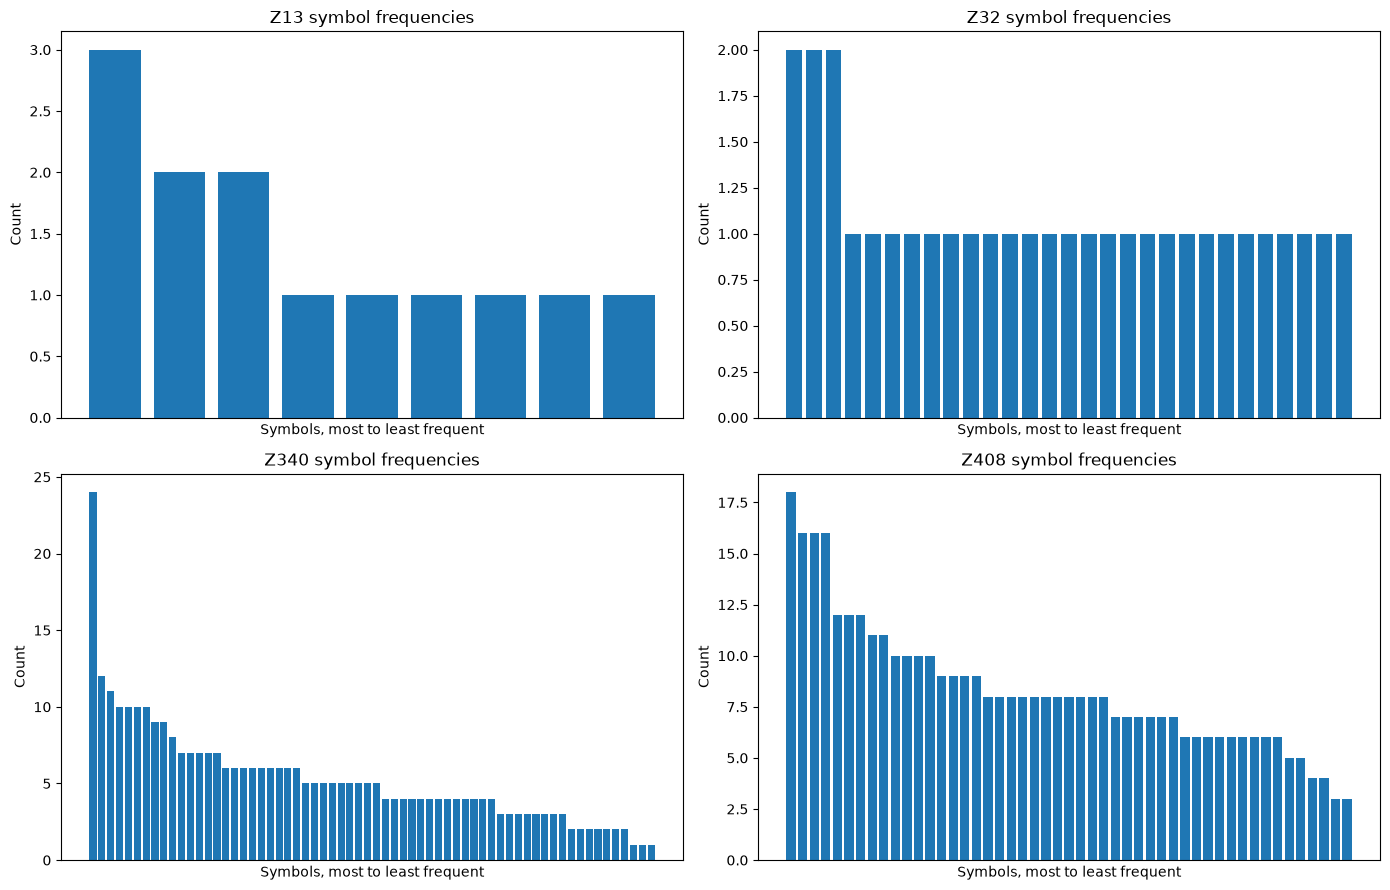

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, (name, symbols) in zip(axes.flat, ciphers.items()):
    frequencies = Counter(symbols).most_common()
    axis.bar(range(len(frequencies)), [count for _, count in frequencies])
    axis.set(title=f'{name} symbol frequencies', xlabel='Symbols, most to least frequent', ylabel='Count')
    axis.set_xticks([])
fig.tight_layout()
plt.show()

## Observations

In [5]:
solved = ('Z408', 'Z340')
unsolved = ('Z13', 'Z32')
print(f"The solved ciphers are much longer ({results['Z340']['length']} and {results['Z408']['length']} symbols) than the unsolved ciphers ({results['Z13']['length']} and {results['Z32']['length']}).")
for name in solved + unsolved:
    values = results[name]
    print(f"{name}: {values['unique_symbols']} unique symbols, entropy {values['entropy_bits']:.3f} bits, IC {values['index_of_coincidence']:.4f}, {values['repeated_bigrams']} repeated bigrams, and {values['repeated_trigrams']} repeated trigrams.")
print('Because Z13 and Z32 are short, their frequency, entropy, coincidence, and repetition estimates are less stable; these measurements alone do not support a decryption claim.')

The solved ciphers are much longer (340 and 408 symbols) than the unsolved ciphers (13 and 32).
Z408: 49 unique symbols, entropy 5.512 bits, IC 0.0211, 59 repeated bigrams, and 10 repeated trigrams.
Z340: 64 unique symbols, entropy 5.752 bits, IC 0.0194, 20 repeated bigrams, and 2 repeated trigrams.
Z13: 9 unique symbols, entropy 3.027 bits, IC 0.0641, 0 repeated bigrams, and 0 repeated trigrams.
Z32: 29 unique symbols, entropy 4.812 bits, IC 0.0060, 0 repeated bigrams, and 0 repeated trigrams.
Because Z13 and Z32 are short, their frequency, entropy, coincidence, and repetition estimates are less stable; these measurements alone do not support a decryption claim.
